# Pit Shell and Blast Master Generator

This notebook is a working build-up of a pit shell and blast master layout.

Starting with a simple pit footprint, then stepping through:
- defining the toe line from bench geometry;
- carving out the trim buffer;
- placing the ramp and slot;
- generating the first production blast;
- then manually laying out the remaining production blasts.

The idea is to keep this as a clean, controlled baseline before automating more of the logic later. Most of this is about getting the geometry behaving properly and making sure the patterns look and feel realistic.

Later on I’ll expand this into sequencing, full blast master generation, and exporting something usable downstream.

## 1. Imports

Pulling in the core libraries for geometry, data handling and plotting.

Shapely does most of the heavy lifting for the geometry. Matplotlib is just for quick visual checks.

In [1]:
import os
import math
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely.geometry import LineString
from shapely.ops import substring
import ipywidgets as widgets
import plotly.graph_objects as go
from IPython.display import display, clear_output



## 2. Inputs

All the main user inputs live here - pit size, bench geometry, trim width, ramp settings, slot size, etc.

If something looks off later, this is the first place to come back to.

In [2]:
# --- Pit shell footprint ---
strike_length_m = 550.0
pit_width_m = 280.0
centre_x = 363600.0
centre_y = 6591800.0

# --- Shell realism ---
n_boundary_points = 180
irregularity_pct = 0.01
smoothing_window = 11
random_seed = 42

# --- Bench / toe-line geometry ---
crest_rl = 200.0
bench_height_m = 10.0
wall_angle_deg = 80.0

# --- Trim buffer ---
trim_buffer_width_m = 30.0

# --- Ramp design ---
ramp_side = "south"
ramp_gradient_ratio = 10.0
ramp_width_m = trim_buffer_width_m

# --- Slot pattern ---
slot_length_m = 60.0
slot_width_m = 45.0
slot_development_direction = "clockwise"  # "clockwise" or "counterclockwise"

# --- Production blast design ---
first_production_blast_depth_m = 80.0

# ============================================================
# DERIVED VALUES
# ============================================================

floor_rl = crest_rl - bench_height_m
wall_angle_rad = math.radians(wall_angle_deg)
toe_offset_m = bench_height_m / math.tan(wall_angle_rad)

ramp_length_m = bench_height_m * ramp_gradient_ratio

print(f"Floor RL: {floor_rl:.2f} m")
print(f"Toe-line inward offset: {toe_offset_m:.2f} m")
print(f"Trim buffer width: {trim_buffer_width_m:.1f} m")
print(f"Ramp gradient: 1:{ramp_gradient_ratio:.1f}")
print(f"Ramp width: {ramp_width_m:.1f} m")
print(f"Required ramp length: {ramp_length_m:.1f} m")
print(f"Slot length: {slot_length_m:.1f} m")
print(f"Slot width: {slot_width_m:.1f} m")
print(f"First production blast depth: {first_production_blast_depth_m:.1f} m")

Floor RL: 190.00 m
Toe-line inward offset: 1.76 m
Trim buffer width: 30.0 m
Ramp gradient: 1:10.0
Ramp width: 30.0 m
Required ramp length: 100.0 m
Slot length: 60.0 m
Slot width: 45.0 m
First production blast depth: 80.0 m


## 3. Helper functions

A mix of geometry utilities and small helpers used throughout.

Nothing fancy here - just keeping the main cells cleaner so the workflow is easier to follow.

In [3]:
def smooth_cyclic(values: np.ndarray, window: int) -> np.ndarray:
    """Smooth a cyclic 1D array using a centred moving average."""
    window = int(max(1, window))

    if window % 2 == 0:
        window += 1

    if window <= 1:
        return values

    pad = window // 2
    padded = np.r_[values[-pad:], values, values[:pad]]
    kernel = np.ones(window) / window

    return np.convolve(padded, kernel, mode="valid")


def create_irregular_pit_shell(
    strike_length: float,
    pit_width: float,
    centre: tuple[float, float],
    n_points: int,
    irregularity: float,
    smoothing_window: int,
    seed: int,
) -> np.ndarray:
    """Create an irregular east-west elongated pit shell polygon."""
    rng = np.random.default_rng(seed)
    theta = np.linspace(0, 2 * np.pi, n_points, endpoint=False)

    noise = rng.normal(0, 1, n_points)
    smooth_noise = smooth_cyclic(noise, smoothing_window)
    smooth_noise = smooth_noise / max(np.max(np.abs(smooth_noise)), 1e-9)

    radial_multiplier = 1.0 + irregularity * smooth_noise

    a = strike_length / 2.0
    b = pit_width / 2.0
    cx, cy = centre

    x = cx + a * np.cos(theta) * radial_multiplier
    y = cy + b * np.sin(theta) * radial_multiplier

    return np.column_stack([x, y])


def clean_polygon(poly: Polygon) -> Polygon:
    """Repair minor invalid polygon geometry."""
    if not poly.is_valid:
        poly = poly.buffer(0)
    return poly


def inward_offset_polygon(coords: np.ndarray, offset_distance: float) -> np.ndarray:
    """Offset a polygon inward using Shapely negative buffer."""
    if offset_distance <= 0:
        return coords.copy()

    poly = clean_polygon(Polygon(coords))
    inner = poly.buffer(-offset_distance, join_style=2)

    if inner.is_empty:
        raise ValueError("Inward offset collapsed the polygon.")

    if inner.geom_type == "MultiPolygon":
        inner = max(inner.geoms, key=lambda g: g.area)

    return np.array(inner.exterior.coords[:-1])


def polygon_area(coords: np.ndarray) -> float:
    """Calculate polygon area using the shoelace formula."""
    x = coords[:, 0]
    y = coords[:, 1]

    return 0.5 * abs(
        np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))
    )


def coords_to_dataframe(coords: np.ndarray, line_name: str, rl: float) -> pd.DataFrame:
    """Convert polygon coordinates to a tidy dataframe."""
    df = pd.DataFrame(coords, columns=["x", "y"])
    df.insert(0, "point_id", np.arange(1, len(df) + 1))
    df.insert(1, "line_name", line_name)
    df["rl"] = rl

    return df


def circular_substring(line: LineString, start_dist: float, length: float) -> LineString:
    """Extract a section from a closed LineString, allowing wrap-around."""
    total_length = line.length
    start_dist = start_dist % total_length
    end_dist = start_dist + length

    if end_dist <= total_length:
        return substring(line, start_dist, end_dist)

    first_part = substring(line, start_dist, total_length)
    second_part = substring(line, 0, end_dist - total_length)

    coords = list(first_part.coords) + list(second_part.coords)
    return LineString(coords)


def compactness_ratio(geom) -> float:
    """Simple shape-quality check based on minimum rotated rectangle."""
    if geom.is_empty or geom.area <= 0:
        return 0.0

    min_rect = geom.minimum_rotated_rectangle

    if min_rect.area <= 0:
        return 0.0

    return geom.area / min_rect.area


def plot_polygon(
    ax,
    geom,
    facecolor="none",
    edgecolor="black",
    alpha=1.0,
    linewidth=2,
    label=None,
):
    """Plot a Shapely Polygon or MultiPolygon."""
    if geom.is_empty:
        return

    if geom.geom_type == "Polygon":
        geoms = [geom]
    elif geom.geom_type == "MultiPolygon":
        geoms = list(geom.geoms)
    else:
        return

    for poly in geoms:
        x, y = poly.exterior.xy

        ax.fill(
            x,
            y,
            facecolor=facecolor,
            edgecolor=edgecolor,
            alpha=alpha,
            linewidth=linewidth,
            label=label,
        )

        label = None

        for interior in poly.interiors:
            ix, iy = interior.xy
            ax.fill(ix, iy, facecolor="white", edgecolor=edgecolor, linewidth=1)


from matplotlib.ticker import FormatStrFormatter

def setup_plan_axis(ax, title: str):
    """Apply common formatting to plan-view plots."""
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Easting / X (m)")
    ax.set_ylabel("Northing / Y (m)")
    ax.grid(True, alpha=0.25)

    ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

    ax.legend(loc="upper right")
    
def get_reference_boundary_point(boundary: LineString, side: str) -> tuple[float, float]:
    """Return the boundary point used to place the ramp."""
    coords = list(boundary.coords)

    if side.lower() == "south":
        idx = min(range(len(coords)), key=lambda i: coords[i][1])
    elif side.lower() == "north":
        idx = max(range(len(coords)), key=lambda i: coords[i][1])
    elif side.lower() == "east":
        idx = max(range(len(coords)), key=lambda i: coords[i][0])
    elif side.lower() == "west":
        idx = min(range(len(coords)), key=lambda i: coords[i][0])
    else:
        raise ValueError("side must be one of: south, north, east, west.")

    return coords[idx]


def make_boundary_rectangle(
    segment: LineString,
    reference_polygon: Polygon,
    offset_inward_m: float,
    depth_m: float,
) -> Polygon:
    """
    Create a straight-sided rectangular polygon from a boundary segment.

    The rectangle uses the segment start and end points as its width direction.
    It is then projected inward from the reference polygon boundary.
    """
    coords = list(segment.coords)

    if len(coords) < 2:
        raise ValueError("Segment must contain at least two coordinates.")

    p0 = np.array(coords[0], dtype=float)
    p1 = np.array(coords[-1], dtype=float)

    tangent = p1 - p0
    tangent_length = np.linalg.norm(tangent)

    if tangent_length <= 1e-9:
        raise ValueError("Segment has negligible length.")

    tangent = tangent / tangent_length

    # Two possible normals
    n1 = np.array([-tangent[1], tangent[0]])
    n2 = np.array([tangent[1], -tangent[0]])

    midpoint = (p0 + p1) / 2.0
    centroid = np.array([reference_polygon.centroid.x, reference_polygon.centroid.y])

    # Select the normal that points inward towards the polygon centroid
    inward = n1 if np.dot(centroid - midpoint, n1) > np.dot(centroid - midpoint, n2) else n2

    outer_left = p0 + inward * offset_inward_m
    outer_right = p1 + inward * offset_inward_m
    inner_right = p1 + inward * (offset_inward_m + depth_m)
    inner_left = p0 + inward * (offset_inward_m + depth_m)

    return Polygon([outer_left, outer_right, inner_right, inner_left])


def geometry_area_ratio(candidate: Polygon, clipped) -> float:
    """Return clipped area as a proportion of original candidate area."""
    if candidate.is_empty or candidate.area <= 0:
        return 0.0

    if clipped.is_empty:
        return 0.0

    return clipped.area / candidate.area


def refresh_edit_pattern_options():
    """Refresh dropdown list of editable manual production blasts."""
    edit_pattern_dropdown.options = [
        (f"Pattern {b['pattern_id']} — {b['pattern_type']}", b["pattern_id"])
        for b in manual_production_blasts
    ]


def get_manual_blast_by_id(pattern_id):
    """Return manual blast dictionary by pattern ID."""
    for blast in manual_production_blasts:
        if blast["pattern_id"] == pattern_id:
            return blast

    return None


def clear_edit_markers():
    """Remove visible edit markers and edit outline."""
    global selected_vertex_marker, edit_polygon_line

    for artist in edit_vertex_markers:
        artist.remove()

    edit_vertex_markers.clear()

    if selected_vertex_marker is not None:
        selected_vertex_marker.remove()
        selected_vertex_marker = None

    if edit_polygon_line is not None:
        edit_polygon_line.remove()
        edit_polygon_line = None

    fig.canvas.draw_idle()


def load_selected_polygon_for_edit():
    """Load selected polygon vertices into editable state."""
    global edit_vertices, selected_vertex_idx, edit_polygon_line

    clear_edit_markers()
    selected_vertex_idx = None
    edit_vertices = []

    if not manual_production_blasts:
        status.value = "<b>Status:</b> No manual blasts available to edit."
        return

    pattern_id = edit_pattern_dropdown.value
    blast = get_manual_blast_by_id(pattern_id)

    if blast is None:
        status.value = "<b>Status:</b> Selected blast not found."
        return

    coords = list(blast["polygon"].exterior.coords)

    if len(coords) > 1 and coords[0] == coords[-1]:
        coords = coords[:-1]

    edit_vertices = [(float(x), float(y)) for x, y in coords]

    xs = [p[0] for p in edit_vertices] + [edit_vertices[0][0]]
    ys = [p[1] for p in edit_vertices] + [edit_vertices[0][1]]

    # Draw connecting lines between editable vertices.
    edit_polygon_line, = ax.plot(
        xs,
        ys,
        linestyle="-",
        linewidth=2.5,
        color="yellow",
        zorder=10,
        label="Editable polygon outline",
    )

    marker = ax.scatter(
        [p[0] for p in edit_vertices],
        [p[1] for p in edit_vertices],
        s=60,
        facecolor="yellow",
        edgecolor="black",
        zorder=11,
        label="Editable vertices",
    )

    edit_vertex_markers.append(marker)

    status.value = (
        f"<b>Status:</b> Editing Pattern {pattern_id}. "
        "Click a yellow vertex to select it, then click the new location."
    )

    fig.canvas.draw_idle()


def nearest_edit_vertex(x, y):
    """Return nearest editable vertex index and distance."""
    if not edit_vertices:
        return None, None

    pts = np.array(edit_vertices)
    distances = np.sqrt((pts[:, 0] - x) ** 2 + (pts[:, 1] - y) ** 2)

    idx = int(np.argmin(distances))
    return idx, float(distances[idx])


def update_selected_vertex_marker():
    """Show the currently selected vertex."""
    global selected_vertex_marker

    if selected_vertex_marker is not None:
        selected_vertex_marker.remove()
        selected_vertex_marker = None

    if selected_vertex_idx is None:
        return

    x, y = edit_vertices[selected_vertex_idx]

    selected_vertex_marker = ax.scatter(
        [x],
        [y],
        s=110,
        facecolor="red",
        edgecolor="black",
        zorder=11,
        label="Selected vertex",
    )

    fig.canvas.draw_idle()


def redraw_manual_blast_artists():
    """Redraw all manual production blast polygons."""
    for group in saved_blast_artist_groups:
        for artist in group:
            artist.remove()
    
    saved_blast_artist_groups.clear()
    saved_artists.clear()

    for label in saved_blast_labels:
        label.remove()
    
    saved_blast_labels.clear()

    for blast in manual_production_blasts:
        x, y = blast["polygon"].exterior.xy

        style = get_blast_style(blast["pattern_type"])

        artist_group = ax.fill(
            x,
            y,
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            alpha=style["alpha"],
            linewidth=1.5,
            label=f"Pattern {blast['pattern_id']} — {style['label_suffix']}",
        )

        label_artist = add_blast_label(
            blast["pattern_id"],
            blast["polygon"],
        )
        
        if label_artist is not None:
            saved_blast_labels.append(label_artist)
        
        saved_artists.extend(artist_group)
        saved_blast_artist_groups.append(artist_group)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        frameon=True,
    )

    fig.canvas.draw_idle()

def show_manual_blasts_for_drawing():
    """Ensure saved manual production blasts are visible while drawing new blasts."""
    redraw_manual_blast_artists()

    status.value = (
        f"<b>Status:</b> Draw mode. "
        f"Existing manual blasts are shown. "
        f"Click points to begin Pattern {next_pattern_id()}."
    )

## 4. Pit shell → toe line → trim → ramp

Build the base geometry.

- generate the pit shell;
- offset to get the toe line;
- create the trim buffer from the toe (not the crest);
- drop in the ramp along the boundary.

This sets up the working area for everything that follows.

In [4]:
pit_shell_xy = create_irregular_pit_shell(
    strike_length=strike_length_m,
    pit_width=pit_width_m,
    centre=(centre_x, centre_y),
    n_points=n_boundary_points,
    irregularity=irregularity_pct,
    smoothing_window=smoothing_window,
    seed=random_seed,
)

toe_line_xy = inward_offset_polygon(pit_shell_xy, toe_offset_m)

pit_shell_polygon = clean_polygon(Polygon(pit_shell_xy))
toe_line_polygon = clean_polygon(Polygon(toe_line_xy))

# Blast design starts from the toe line, not the crest.
design_boundary_polygon = toe_line_polygon
design_boundary = LineString(design_boundary_polygon.exterior.coords)

inner_trim_edge_polygon = design_boundary_polygon.buffer(-trim_buffer_width_m)

if inner_trim_edge_polygon.is_empty:
    raise ValueError(
        "Trim buffer width is too large. The inward buffer collapsed the toe-line polygon."
    )

trim_buffer_zone = design_boundary_polygon.difference(inner_trim_edge_polygon)

# --- Ramp placement ---
ramp_point = get_reference_boundary_point(design_boundary, ramp_side)
ramp_centre_distance = design_boundary.project(Point(ramp_point))

ramp_start_distance = max(0, ramp_centre_distance - ramp_length_m / 2)
ramp_end_distance = min(design_boundary.length, ramp_centre_distance + ramp_length_m / 2)

ramp_outer_segment = substring(
    design_boundary,
    ramp_start_distance,
    ramp_end_distance,
)

ramp_corridor = ramp_outer_segment.buffer(
    ramp_width_m * 1.5,
    cap_style=2,
    join_style=2,
)

final_ramp_polygon = trim_buffer_zone.intersection(ramp_corridor)

if final_ramp_polygon.is_empty:
    raise ValueError(
        "Final ramp polygon is empty. Try reducing ramp length, trim width, or changing ramp side."
    )

trim_blast_zone_excluding_ramp = trim_buffer_zone.difference(final_ramp_polygon)

summary = pd.DataFrame([
    {
        "geometry": "pit_shell_crest",
        "rl": crest_rl,
        "area_m2": pit_shell_polygon.area,
    },
    {
        "geometry": "toe_line_floor",
        "rl": floor_rl,
        "area_m2": toe_line_polygon.area,
    },
    {
        "geometry": "toe_based_trim_buffer",
        "rl": floor_rl,
        "area_m2": trim_buffer_zone.area,
    },
    {
        "geometry": "final_ramp",
        "rl": floor_rl,
        "area_m2": final_ramp_polygon.area,
    },
])

summary

,geometry,rl,area_m2
0,pit_shell_crest,200.0,120687.552343
1,toe_line_floor,190.0,118339.075267
2,toe_based_trim_buffer,190.0,36953.673392
3,final_ramp,190.0,2935.249419


## 5. Slot + first production blast

Start the actual blast layout.

The slot runs off the ramp along the boundary, then the first production blast fires back into that slot.

At this point everything is still fairly controlled — no weird geometry yet.

In [5]:
# --- Slot starts at one end of the ramp ---
if slot_development_direction.lower() == "clockwise":
    slot_start_distance = ramp_end_distance
    slot_signed_length = slot_length_m

elif slot_development_direction.lower() == "counterclockwise":
    slot_start_distance = ramp_start_distance
    slot_signed_length = -slot_length_m

else:
    raise ValueError("slot_development_direction must be 'clockwise' or 'counterclockwise'.")


if slot_signed_length >= 0:
    slot_outer_segment = circular_substring(
        design_boundary,
        slot_start_distance,
        slot_signed_length,
    )
else:
    reversed_boundary = LineString(list(design_boundary.coords)[::-1])
    reversed_start = reversed_boundary.project(
        design_boundary.interpolate(slot_start_distance)
    )

    slot_outer_segment = circular_substring(
        reversed_boundary,
        reversed_start,
        abs(slot_signed_length),
    )


# --- Slot sits inside toe-based trim buffer ---
slot_corridor = slot_outer_segment.buffer(
    slot_width_m,
    cap_style=2,
    join_style=2,
)

slot_pattern_polygon = slot_corridor.intersection(trim_blast_zone_excluding_ramp)

if slot_pattern_polygon.is_empty:
    raise ValueError(
        "Slot pattern polygon is empty. Try increasing slot width or changing ramp/slot direction."
    )

trim_blast_zone_remaining = trim_blast_zone_excluding_ramp.difference(slot_pattern_polygon)


# --- First production blast behind the slot ---
first_production_candidate = make_boundary_rectangle(
    segment=slot_outer_segment,
    reference_polygon=design_boundary_polygon,
    offset_inward_m=trim_buffer_width_m,
    depth_m=first_production_blast_depth_m,
)

first_production_blast_polygon = first_production_candidate.intersection(
    design_boundary_polygon.difference(trim_buffer_zone)
)

if first_production_blast_polygon.is_empty:
    raise ValueError(
        "First production blast polygon is empty. Try increasing first production blast depth."
    )

print("Ramp, slot and first production blast generated successfully.")
print(f"Ramp area: {final_ramp_polygon.area:,.0f} m²")
print(f"Slot area: {slot_pattern_polygon.area:,.0f} m²")
print(f"First production blast area: {first_production_blast_polygon.area:,.0f} m²")

# ---------------------------------------------------------------------
# Export first 3 blast polygons: Ramp + Slot + First Production
# ---------------------------------------------------------------------

from pathlib import Path
from shapely.geometry import Polygon, MultiPolygon
from shapely.validation import make_valid

first_three_blast_polygons = [
    {
        "pattern_id": 1,
        "pattern_type": "Ramp",
        "geometry": final_ramp_polygon,
        "width_m": ramp_width_m,
        "length_m": ramp_length_m,
        "rl": floor_rl,
    },
    {
        "pattern_id": 2,
        "pattern_type": "Slot",
        "geometry": slot_pattern_polygon,
        "width_m": slot_width_m,
        "length_m": slot_length_m,
        "rl": floor_rl,
    },
    {
        "pattern_id": 3,
        "pattern_type": "Production",
        "geometry": first_production_blast_polygon,
        "width_m": None,
        "length_m": first_production_blast_depth_m,
        "rl": floor_rl,
    },
]

export_rows = []

for blast in first_three_blast_polygons:
    pattern_id = blast["pattern_id"]
    pattern_type = blast["pattern_type"]
    geom = make_valid(blast["geometry"])

    if geom.is_empty:
        print(f"Skipping pattern {pattern_id} ({pattern_type}) because geometry is empty.")
        continue

    if isinstance(geom, MultiPolygon):
        polygon_parts = list(geom.geoms)
    elif isinstance(geom, Polygon):
        polygon_parts = [geom]
    else:
        raise TypeError(
            f"Pattern {pattern_id} ({pattern_type}) geometry is not a Polygon or MultiPolygon."
        )

    for polygon_part, polygon in enumerate(polygon_parts, start=1):
        exterior_coords = list(polygon.exterior.coords)

        for point_order, coord in enumerate(exterior_coords, start=1):
            x, y = coord[:2]

            export_rows.append({
                "pattern_id": pattern_id,
                "pattern_type": pattern_type,
                "polygon_part": polygon_part,
                "point_order": point_order,
                "x": x,
                "y": y,
                "rl": blast["rl"],
                "width_m": blast["width_m"],
                "length_m": blast["length_m"],
                "area_m2": polygon.area,
                "wkt": polygon.wkt,
            })

first_three_blast_polygon_export_df = pd.DataFrame(export_rows)

output_dir = Path("exports")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "first_3_blast_polygons.csv"
first_three_blast_polygon_export_df.to_csv(output_path, index=False)

print(
    f"Exported {first_three_blast_polygon_export_df['pattern_id'].nunique()} "
    f"blast polygon(s) to: {output_path}"
)

first_three_blast_polygon_export_df.head()

Ramp, slot and first production blast generated successfully.
Ramp area: 2,935 m²
Slot area: 1,758 m²
First production blast area: 4,794 m²
Exported 3 blast polygon(s) to: exports\first_3_blast_polygons.csv


,pattern_id,pattern_type,polygon_part,point_order,x,y,rl,width_m,length_m,area_m2,wkt
0,1,Ramp,1,1,363647.730715,6.591664e+06,190.0,30.0,100.0,2935.249419,POLYGON ((363647.73071457713 6591663.582818910...
1,1,Ramp,1,2,363638.176051,6.591663e+06,190.0,30.0,100.0,2935.249419,POLYGON ((363647.73071457713 6591663.582818910...
2,1,Ramp,1,3,363628.673178,6.591662e+06,190.0,30.0,100.0,2935.249419,POLYGON ((363647.73071457713 6591663.582818910...
3,1,Ramp,1,4,363619.136434,6.591662e+06,190.0,30.0,100.0,2935.249419,POLYGON ((363647.73071457713 6591663.582818910...
4,1,Ramp,1,5,363609.569439,6.591661e+06,190.0,30.0,100.0,2935.249419,POLYGON ((363647.73071457713 6591663.582818910...


## 6. Quick visual check

Plot everything so far - pit, toe, trim, ramp, slot and first production blast.

Just a sanity check before moving into manual pattern layout.

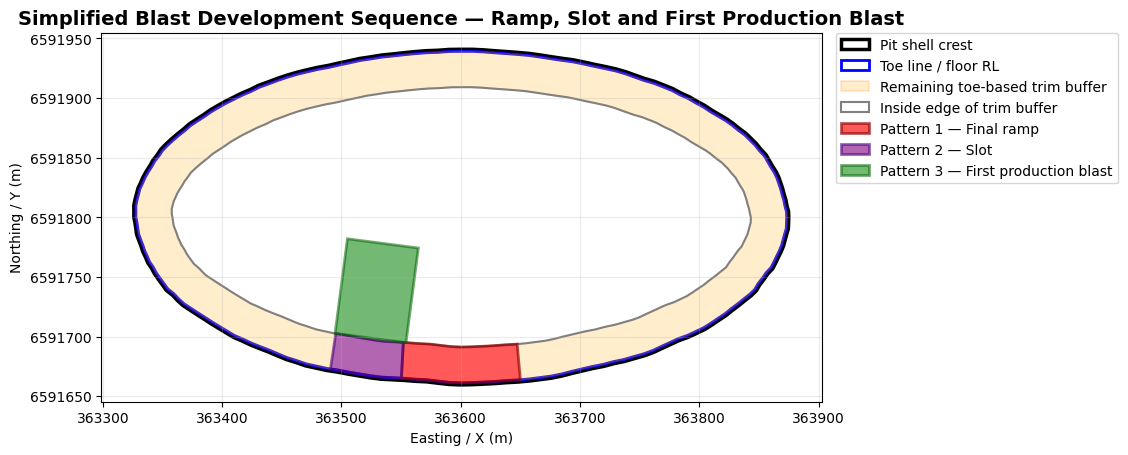

In [6]:
fig, ax = plt.subplots(figsize=(11, 8))

plot_polygon(
    ax,
    pit_shell_polygon,
    facecolor="none",
    edgecolor="black",
    linewidth=2.5,
    label="Pit shell crest",
)

plot_polygon(
    ax,
    toe_line_polygon,
    facecolor="none",
    edgecolor="blue",
    linewidth=2,
    label="Toe line / floor RL",
)

plot_polygon(
    ax,
    trim_blast_zone_remaining,
    facecolor="orange",
    edgecolor="darkorange",
    alpha=0.20,
    linewidth=1.2,
    label="Remaining toe-based trim buffer",
)

plot_polygon(
    ax,
    inner_trim_edge_polygon,
    facecolor="none",
    edgecolor="grey",
    linewidth=1.5,
    label="Inside edge of trim buffer",
)

plot_polygon(
    ax,
    final_ramp_polygon,
    facecolor="red",
    edgecolor="darkred",
    alpha=0.65,
    linewidth=2,
    label="Pattern 1 — Final ramp",
)

plot_polygon(
    ax,
    slot_pattern_polygon,
    facecolor="purple",
    edgecolor="indigo",
    alpha=0.60,
    linewidth=2,
    label="Pattern 2 — Slot",
)

plot_polygon(
    ax,
    first_production_blast_polygon,
    facecolor="green",
    edgecolor="darkgreen",
    alpha=0.55,
    linewidth=2,
    label="Pattern 3 — First production blast",
)

setup_plan_axis(
    ax,
    "Simplified Blast Development Sequence — Ramp, Slot and First Production Blast",
)

# Create legend outside the plot
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),  # push outside right
    borderaxespad=0,
    frameon=True
)

# Make space for the legend
plt.subplots_adjust(right=0.78)

plt.show()

## 7. Setup for manual production blasts

Initialise storage for the production blasts that I’m going to draw manually.

Keeping these separate so they can be reviewed, adjusted, and exported later.

In [7]:
manual_production_blasts = []
current_polygon_points = []

blast_counter_start = 4  # Pattern 1 = ramp, 2 = slot, 3 = first production blast

print("Manual production blast storage initialised.")
print("Next production blast will be Pattern 4.")

Manual production blast storage initialised.
Next production blast will be Pattern 4.


In [8]:
# ============================================================
# LOAD EXISTING MANUAL BLAST DATASET
# ============================================================

load_file_input = widgets.Text(
    value="exports/manual_blast_geometry.csv",
    description="Geometry CSV:",
    layout=widgets.Layout(width="650px"),
)

load_button = widgets.Button(
    description="Load Existing Blasts",
    button_style="info",
)

load_status = widgets.HTML(value="<b>Status:</b> No existing blast file loaded.")


def load_manual_blast_geometry(csv_path: str):
    """
    Load manually drawn blast polygons from a saved geometry CSV.

    Expected columns:
    - pattern_id
    - pattern_type
    - point_id
    - x
    - y
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Could not find file: {csv_path}")

    df = pd.read_csv(csv_path)

    required_cols = {"pattern_id", "pattern_type", "point_id", "x", "y"}
    missing = required_cols.difference(df.columns)

    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    loaded_blasts = []

    for pattern_id, group in df.groupby("pattern_id"):
        group = group.sort_values("point_id")

        coords = list(zip(group["x"], group["y"]))

        # Remove duplicated closing point if present
        if len(coords) > 1 and coords[0] == coords[-1]:
            coords = coords[:-1]

        poly = Polygon(coords)

        if not poly.is_valid:
            poly = poly.buffer(0)

        if poly.is_empty or poly.area <= 0:
            continue

        loaded_blasts.append({
            "pattern_id": int(pattern_id),
            "pattern_type": group["pattern_type"].iloc[0],
            "polygon": poly,
            "area_m2": poly.area,
        })

    return loaded_blasts


def on_load_clicked(_):
    global manual_production_blasts

    try:
        loaded = load_manual_blast_geometry(load_file_input.value)

        manual_production_blasts.clear()
        manual_production_blasts.extend(loaded)

        load_status.value = (
            f"<b>Status:</b> Loaded {len(manual_production_blasts)} manual blast(s) "
            f"from <code>{load_file_input.value}</code>."
        )

    except Exception as e:
        load_status.value = f"<b>Status:</b> Load failed — {e}"


load_button.on_click(on_load_clicked)

display(widgets.VBox([
    widgets.HBox([load_file_input, load_button]),
    load_status,
]))

## 8. Draw production blasts (manual)

Interactive canvas for laying out the remaining blasts.

Click points to sketch out a polygon, then save it as a blast. Repeat for each pattern.

This is intentionally manual for now - easier to control the geometry and avoid the odd shapes that crept in with the automated approach.

In [9]:
%matplotlib widget

In [10]:
plt.ioff()

fig, ax = plt.subplots(figsize=(11, 8))

fig.canvas.toolbar_visible = False
fig.canvas.header_visible = False
fig.canvas.footer_visible = True
fig.canvas.resizable = True

# ------------------------------------------------------------
# Base geometry
# ------------------------------------------------------------

plot_polygon(
    ax,
    pit_shell_polygon,
    facecolor="none",
    edgecolor="black",
    linewidth=2.5,
    label="Pit shell crest",
)

plot_polygon(
    ax,
    toe_line_polygon,
    facecolor="none",
    edgecolor="blue",
    linewidth=2,
    label="Toe line / floor RL",
)

plot_polygon(
    ax,
    trim_blast_zone_remaining,
    facecolor="orange",
    edgecolor="darkorange",
    alpha=0.20,
    linewidth=1.2,
    label="Remaining toe-based trim buffer",
)

plot_polygon(
    ax,
    inner_trim_edge_polygon,
    facecolor="none",
    edgecolor="grey",
    linewidth=1.5,
    label="Inside edge of trim buffer",
)

plot_polygon(
    ax,
    final_ramp_polygon,
    facecolor="red",
    edgecolor="darkred",
    alpha=0.65,
    linewidth=2,
    label="Pattern 1 — Final ramp",
)

plot_polygon(
    ax,
    slot_pattern_polygon,
    facecolor="purple",
    edgecolor="indigo",
    alpha=0.60,
    linewidth=2,
    label="Pattern 2 — Slot",
)

plot_polygon(
    ax,
    first_production_blast_polygon,
    facecolor="green",
    edgecolor="darkgreen",
    alpha=0.55,
    linewidth=2,
    label="Pattern 3 — First production blast",
)

ax.set_aspect("equal", adjustable="box")
ax.set_title("Interactive Production Blast Drawing Canvas", fontsize=14, fontweight="bold")
ax.set_xlabel("Easting / X (m)")
ax.set_ylabel("Northing / Y (m)")
ax.grid(True, alpha=0.25)

from matplotlib.ticker import FormatStrFormatter

ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
home_xlim = ax.get_xlim()
home_ylim = ax.get_ylim()

# Move legend outside the drawing area
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    frameon=True,
)

plt.tight_layout()

# ------------------------------------------------------------
# Interactive drawing state
# ------------------------------------------------------------

current_line, = ax.plot([], [], marker="o", linestyle="-", linewidth=2, label="Current polygon")
saved_artists = []
saved_blast_artist_groups = []
saved_blast_labels = []

edit_vertices = []
selected_vertex_idx = None
edit_vertex_markers = []
selected_vertex_marker = None
edit_polygon_line = None

status = widgets.HTML(
    value="<b>Status:</b> Click points to begin drawing Pattern 4."
)

save_button = widgets.Button(
    description="Save Blast",
    button_style="success",
    tooltip="Close and save the current polygon",
)

mode_dropdown = widgets.Dropdown(
    options=["Draw new blast", "Edit existing blast"],
    value="Draw new blast",
    description="Mode:",
    layout=widgets.Layout(width="260px"),
)

blast_type_dropdown = widgets.Dropdown(
    options=["Production", "Trim"],
    value="Production",
    description="Blast type:",
    layout=widgets.Layout(width="240px"),
)

edit_pattern_dropdown = widgets.Dropdown(
    options=[
        (f"Pattern {b['pattern_id']} — {b['pattern_type']}", b["pattern_id"])
        for b in manual_production_blasts
    ],
    description="Edit:",
    layout=widgets.Layout(width="360px"),
)

save_edits_button = widgets.Button(
    description="Save Edits",
    button_style="success",
    tooltip="Save edits to the selected polygon",
)

undo_button = widgets.Button(
    description="Undo Point",
    button_style="warning",
    tooltip="Remove the most recent point",
)

clear_button = widgets.Button(
    description="Clear Current",
    button_style="danger",
    tooltip="Clear the current unsaved polygon",
)

finish_button = widgets.Button(
    description="Finish",
    button_style="primary",
    tooltip="Finish drawing production blasts",
)

undo_blast_button = widgets.Button(
    description="Undo Last Blast",
    button_style="warning",
    tooltip="Remove the most recently saved blast polygon",
)

zoom_in_button = widgets.Button(
    description="Zoom In",
    button_style="",
    tooltip="Zoom in around the current plot centre",
)

zoom_out_button = widgets.Button(
    description="Zoom Out",
    button_style="",
    tooltip="Zoom out around the current plot centre",
)

home_button = widgets.Button(
    description="Home View",
    button_style="",
    tooltip="Reset to the original plot extent",
)

def refresh_current_line():
    """Refresh the temporary polygon line on the canvas."""
    if len(current_polygon_points) == 0:
        current_line.set_data([], [])
    else:
        xs = [p[0] for p in current_polygon_points]
        ys = [p[1] for p in current_polygon_points]
        current_line.set_data(xs, ys)

    fig.canvas.draw_idle()


def next_pattern_id():
    """Return the next manual production blast pattern ID."""
    return blast_counter_start + len(manual_production_blasts)


def on_click(event):
    """Handle canvas clicks for drawing or editing."""
    global selected_vertex_idx

    if event.inaxes != ax:
        return

    if event.xdata is None or event.ydata is None:
        return

    if event.button is not None and str(event.button).lower() not in ["1", "mousebutton.left"]:
        return

    # --------------------------------------------------------
    # Draw new blast mode
    # --------------------------------------------------------
    if mode_dropdown.value == "Draw new blast":
        current_polygon_points.append((event.xdata, event.ydata))

        status.value = (
            f"<b>Status:</b> Drawing Pattern {next_pattern_id()} — "
            f"{len(current_polygon_points)} point(s) selected. "
            f"Last point: ({event.xdata:.1f}, {event.ydata:.1f})"
        )

        refresh_current_line()
        return

    # --------------------------------------------------------
    # Edit existing blast mode
    # --------------------------------------------------------
    if mode_dropdown.value == "Edit existing blast":
        if not edit_vertices:
            load_selected_polygon_for_edit()
            return

        # If no vertex is selected, select nearest vertex.
        if selected_vertex_idx is None:
            idx, dist = nearest_edit_vertex(event.xdata, event.ydata)

            if idx is None:
                return

            selected_vertex_idx = idx
            update_selected_vertex_marker()

            status.value = (
                f"<b>Status:</b> Selected vertex {idx + 1}. "
                "Click a new location to move it."
            )
            return

        # If a vertex is already selected, move it to the clicked location.
        edit_vertices[selected_vertex_idx] = (event.xdata, event.ydata)

        status.value = (
            f"<b>Status:</b> Moved vertex {selected_vertex_idx + 1} "
            f"to ({event.xdata:.1f}, {event.ydata:.1f}). "
            "Click Save Edits to update the polygon."
        )

        selected_vertex_idx = None
        load_selected_polygon_for_edit()


def add_blast_label(pattern_id, polygon):
    """Add the blast number at the polygon centroid."""
    if polygon.is_empty:
        return None

    centroid = polygon.representative_point()

    return ax.text(
        centroid.x,
        centroid.y,
        str(pattern_id),
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="circle,pad=0.25",
            facecolor="white",
            edgecolor="black",
            alpha=0.8,
        ),
        zorder=20,
    )

def on_save_clicked(_):
    """Close and save the current polygon as a production blast."""
    if len(current_polygon_points) < 3:
        status.value = "<b>Status:</b> Select at least 3 points before saving a blast."
        return

    candidate_polygon = Polygon(current_polygon_points)

    if not candidate_polygon.is_valid:
        candidate_polygon = candidate_polygon.buffer(0)

    if candidate_polygon.is_empty or candidate_polygon.area <= 0:
        status.value = "<b>Status:</b> Invalid polygon. Clear current points and redraw."
        return

    # Keep the manually drawn blast inside the available toe-line production area.
    blast_type = blast_type_dropdown.value
    drawing_domain = get_drawing_domain(blast_type)

    saved_polygon = candidate_polygon.intersection(drawing_domain)

    # Prevent overlap with previous fixed patterns and previous manual blasts.
    already_assigned = first_production_blast_polygon

    for blast in manual_production_blasts:
        already_assigned = already_assigned.union(blast["polygon"])

    saved_polygon = saved_polygon.difference(already_assigned)

    if saved_polygon.is_empty or saved_polygon.area <= 0:
        status.value = (
            "<b>Status:</b> Saved polygon has no valid remaining area after clipping. "
            "Try drawing in an unassigned production area."
        )
        return

    if saved_polygon.geom_type == "MultiPolygon":
        saved_polygon = max(saved_polygon.geoms, key=lambda g: g.area)

    pattern_id = next_pattern_id()

    manual_production_blasts.append({
        "pattern_id": pattern_id,
        "pattern_type": blast_type,
        "polygon": saved_polygon,
        "area_m2": saved_polygon.area,
    })

    x, y = saved_polygon.exterior.xy

    style = get_blast_style(blast_type)

    artist_group = ax.fill(
        x,
        y,
        facecolor=style["facecolor"],
        edgecolor=style["edgecolor"],
        alpha=style["alpha"],
        linewidth=1.5,
        label=f"Pattern {pattern_id} — {style['label_suffix']}",
    )
    
    saved_artists.extend(artist_group)
    saved_blast_artist_groups.append(artist_group)

    label_artist = add_blast_label(pattern_id, saved_polygon)

    if label_artist is not None:
        saved_blast_labels.append(label_artist)

    current_polygon_points.clear()
    refresh_current_line()

    status.value = (
        f"<b>Status:</b> Pattern {pattern_id} saved. "
        f"Area = {saved_polygon.area:,.0f} m². "
        f"Click points to begin Pattern {next_pattern_id()}."
    )

    fig.canvas.draw_idle()

    refresh_edit_pattern_options()


def on_undo_clicked(_):
    """Remove the most recent point."""
    if current_polygon_points:
        current_polygon_points.pop()

    status.value = (
        f"<b>Status:</b> Drawing Pattern {next_pattern_id()} — "
        f"{len(current_polygon_points)} point(s) selected."
    )

    refresh_current_line()


def on_clear_clicked(_):
    """Clear the current unsaved polygon."""
    current_polygon_points.clear()

    status.value = (
        f"<b>Status:</b> Current polygon cleared. "
        f"Click points to begin Pattern {next_pattern_id()}."
    )

    refresh_current_line()


def on_finish_clicked(_):
    """Disconnect the click handler and finish drawing."""
    fig.canvas.mpl_disconnect(click_connection_id)

    current_polygon_points.clear()
    refresh_current_line()

    status.value = (
        f"<b>Status:</b> Finished. "
        f"{len(manual_production_blasts)} manual production blast(s) saved."
    )


def on_undo_blast_clicked(_):
    """Remove the most recently saved manual blast polygon."""
    if not manual_production_blasts:
        status.value = "<b>Status:</b> No saved manual blasts to undo."
        return

    removed_blast = manual_production_blasts.pop()

    if saved_blast_artist_groups:
        artist_group = saved_blast_artist_groups.pop()

        for artist in artist_group:
            artist.remove()

    if saved_blast_labels:
        label = saved_blast_labels.pop()
        label.remove()

    # Rebuild legend so the removed blast label disappears.
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        frameon=True,
    )

    status.value = (
        f"<b>Status:</b> Removed Pattern {removed_blast['pattern_id']}. "
        f"Next blast will be Pattern {next_pattern_id()}."
    )

    fig.canvas.draw_idle()

def on_mode_changed(change):
    """Respond to mode changes."""
    global selected_vertex_idx

    if change["name"] != "value":
        return

    selected_vertex_idx = None
    clear_edit_markers()

    if change["new"] == "Edit existing blast":
        refresh_edit_pattern_options()
        redraw_manual_blast_artists()
        load_selected_polygon_for_edit()

    else:
        show_manual_blasts_for_drawing()

def on_edit_pattern_changed(change):
    """Load another polygon when edit selection changes."""
    if change["name"] != "value":
        return

    if mode_dropdown.value == "Edit existing blast":
        load_selected_polygon_for_edit()

def get_drawing_domain(blast_type: str):
    """Return the allowed drawing area for the selected blast type."""
    if blast_type == "Trim":
        return trim_blast_zone_remaining

    if blast_type == "Production":
        return design_boundary_polygon.difference(trim_buffer_zone)

    raise ValueError(f"Unknown blast type: {blast_type}")


def get_blast_style(blast_type: str):
    """Return plotting style for each blast type."""
    if blast_type == "Trim":
        return {
            "facecolor": "orange",
            "edgecolor": "darkorange",
            "alpha": 0.55,
            "label_suffix": "Manual trim",
        }

    return {
        "facecolor": "cyan",
        "edgecolor": "blue",
        "alpha": 0.45,
        "label_suffix": "Manual production",
    }

def on_save_edits_clicked(_):
    """Save edited vertices back into the selected manual blast polygon."""
    global edit_vertices, selected_vertex_idx

    if mode_dropdown.value != "Edit existing blast":
        status.value = "<b>Status:</b> Switch to Edit existing blast mode first."
        return

    if len(edit_vertices) < 3:
        status.value = "<b>Status:</b> Need at least 3 vertices to save polygon edits."
        return

    pattern_id = edit_pattern_dropdown.value
    blast = get_manual_blast_by_id(pattern_id)

    if blast is None:
        status.value = "<b>Status:</b> Selected blast not found."
        return

    edited_poly = Polygon(edit_vertices)

    if not edited_poly.is_valid:
        edited_poly = edited_poly.buffer(0)

    drawing_domain = get_drawing_domain(blast["pattern_type"])
    edited_poly = edited_poly.intersection(drawing_domain)

    if edited_poly.geom_type == "MultiPolygon":
        edited_poly = max(edited_poly.geoms, key=lambda g: g.area)

    if edited_poly.is_empty or edited_poly.area <= 0:
        status.value = "<b>Status:</b> Edited polygon is invalid after clipping."
        return

    blast["polygon"] = edited_poly
    blast["area_m2"] = edited_poly.area

    selected_vertex_idx = None

    redraw_manual_blast_artists()
    load_selected_polygon_for_edit()

    status.value = (
        f"<b>Status:</b> Saved edits to Pattern {pattern_id}. "
        f"Updated area = {edited_poly.area:,.0f} m²."
    )

def zoom_axis(scale_factor):
    """Zoom the current axes around the current centre."""
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    x_mid = (x0 + x1) / 2
    y_mid = (y0 + y1) / 2

    x_half = (x1 - x0) * scale_factor / 2
    y_half = (y1 - y0) * scale_factor / 2

    ax.set_xlim(x_mid - x_half, x_mid + x_half)
    ax.set_ylim(y_mid - y_half, y_mid + y_half)

    fig.canvas.draw_idle()


def on_zoom_in_clicked(_):
    zoom_axis(0.7)


def on_zoom_out_clicked(_):
    zoom_axis(1.3)


def on_home_clicked(_):
    ax.set_xlim(home_xlim)
    ax.set_ylim(home_ylim)
    fig.canvas.draw_idle()

controls_top = widgets.HBox([
    mode_dropdown,
    blast_type_dropdown,
    edit_pattern_dropdown,
    save_edits_button,
])

controls_bottom = widgets.HBox([
    save_button,
    undo_button,
    undo_blast_button,
    clear_button,
    zoom_in_button,
    zoom_out_button,
    home_button,
    finish_button,
])

mode_dropdown.observe(on_mode_changed, names="value")
edit_pattern_dropdown.observe(on_edit_pattern_changed, names="value")
save_edits_button.on_click(on_save_edits_clicked)

click_connection_id = fig.canvas.mpl_connect("button_press_event", on_click)

save_button.on_click(on_save_clicked)
undo_button.on_click(on_undo_clicked)
undo_blast_button.on_click(on_undo_blast_clicked)
clear_button.on_click(on_clear_clicked)
zoom_in_button.on_click(on_zoom_in_clicked)
zoom_out_button.on_click(on_zoom_out_clicked)
home_button.on_click(on_home_clicked)
finish_button.on_click(on_finish_clicked)

plt.subplots_adjust(right=0.75)

ui = widgets.VBox([
    controls_top,
    controls_bottom,
    status,
    fig.canvas,
])

display(ui)

## 9. Summary + export

Convert the drawn blasts into a simple table.

Mainly just checking IDs and areas here, but also exporting so I’ve got something to reuse without redrawing everything.

In [11]:
# Create summary dataframe
manual_blast_summary = pd.DataFrame([
    {
        "pattern_id": blast["pattern_id"],
        "pattern_type": blast["pattern_type"],
        "area_m2": blast["area_m2"],
    }
    for blast in manual_production_blasts
])

# ------------------------------------------------------------
# Define export folder and filenames
# ------------------------------------------------------------

export_dir = "exports"
os.makedirs(export_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

summary_file = os.path.join(export_dir, f"manual_blast_summary_{timestamp}.csv")
geometry_file = os.path.join(export_dir, f"manual_blast_geometry_{timestamp}.csv")

# ------------------------------------------------------------
# Export summary
# ------------------------------------------------------------

manual_blast_summary.to_csv(summary_file, index=False)

# ------------------------------------------------------------
# Build geometry dataframe (vertex-level export)
# ------------------------------------------------------------

geometry_rows = []

for blast in manual_production_blasts:
    poly = blast["polygon"]

    if poly.is_empty:
        continue

    # Handle MultiPolygon safely
    if poly.geom_type == "MultiPolygon":
        poly = max(poly.geoms, key=lambda g: g.area)

    coords = list(poly.exterior.coords)

    for i, (x, y) in enumerate(coords):
        geometry_rows.append({
            "pattern_id": blast["pattern_id"],
            "pattern_type": blast["pattern_type"],
            "point_id": i + 1,
            "x": x,
            "y": y,
        })

geometry_df = pd.DataFrame(geometry_rows)

geometry_df.to_csv(geometry_file, index=False)

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print(f"Summary exported to: {summary_file}")
print(f"Geometry exported to: {geometry_file}")

manual_blast_summary

Summary exported to: exports\manual_blast_summary_20260518_051150.csv
Geometry exported to: exports\manual_blast_geometry_20260518_051150.csv


""


## 10. Convert to 3D

Lift the 2D polygons into 3D.

Bottom is at the floor RL, top is offset back out to the crest using the toe offset. This keeps everything consistent with the bench geometry.

In [12]:
def outward_offset_polygon(poly: Polygon, offset_distance: float) -> Polygon:
    """
    Offset a polygon outward.

    Used here to reconstruct the crest-level footprint from the toe/floor-level
    footprint using the bench toe offset.
    """
    if poly.is_empty:
        return poly

    out = poly.buffer(offset_distance, join_style=2)

    if out.geom_type == "MultiPolygon":
        out = max(out.geoms, key=lambda g: g.area)

    return out


def polygon_to_3d_vertices(
    poly: Polygon,
    pattern_id: int,
    pattern_type: str,
    bottom_rl: float,
    top_rl: float,
    toe_offset: float,
    current_polygon_is_toe_based: bool = True,
) -> pd.DataFrame:
    """
    Convert a 2D blast polygon into top and bottom 3D vertices.

    If current_polygon_is_toe_based=True:
        - input polygon is treated as the bottom/floor/toe footprint
        - top polygon is offset outward by toe_offset

    If current_polygon_is_toe_based=False:
        - input polygon is treated as the top/crest footprint
        - bottom polygon is offset inward by toe_offset
    """
    if poly.is_empty:
        return pd.DataFrame()

    if poly.geom_type == "MultiPolygon":
        poly = max(poly.geoms, key=lambda g: g.area)

    poly = clean_polygon(poly)

    if current_polygon_is_toe_based:
        bottom_poly = poly
        top_poly = outward_offset_polygon(poly, toe_offset)
    else:
        top_poly = poly
        bottom_poly = poly.buffer(-toe_offset, join_style=2)

        if bottom_poly.geom_type == "MultiPolygon":
            bottom_poly = max(bottom_poly.geoms, key=lambda g: g.area)

    bottom_coords = list(bottom_poly.exterior.coords)
    top_coords = list(top_poly.exterior.coords)

    rows = []

    for i, (x, y) in enumerate(bottom_coords, start=1):
        rows.append({
            "pattern_id": pattern_id,
            "pattern_type": pattern_type,
            "surface": "bottom_toe_floor",
            "vertex_id": i,
            "x": x,
            "y": y,
            "z_rl": bottom_rl,
        })

    for i, (x, y) in enumerate(top_coords, start=1):
        rows.append({
            "pattern_id": pattern_id,
            "pattern_type": pattern_type,
            "surface": "top_crest",
            "vertex_id": i,
            "x": x,
            "y": y,
            "z_rl": top_rl,
        })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Build list of all blast polygons
# ------------------------------------------------------------

blast_polygons = [
    {
        "pattern_id": 1,
        "pattern_type": "Ramp",
        "polygon": final_ramp_polygon,
    },
    {
        "pattern_id": 2,
        "pattern_type": "Slot",
        "polygon": slot_pattern_polygon,
    },
    {
        "pattern_id": 3,
        "pattern_type": "First production blast",
        "polygon": first_production_blast_polygon,
    },
]

for blast in manual_production_blasts:
    blast_polygons.append({
        "pattern_id": blast["pattern_id"],
        "pattern_type": blast["pattern_type"],
        "polygon": blast["polygon"],
    })


# ------------------------------------------------------------
# Convert to 3D vertex table
# ------------------------------------------------------------

blast_3d_vertices_df = pd.concat(
    [
        polygon_to_3d_vertices(
            poly=blast["polygon"],
            pattern_id=blast["pattern_id"],
            pattern_type=blast["pattern_type"],
            bottom_rl=floor_rl,
            top_rl=crest_rl,
            toe_offset=toe_offset_m,
            current_polygon_is_toe_based=True,
        )
        for blast in blast_polygons
    ],
    ignore_index=True,
)

blast_3d_vertices_df

,pattern_id,pattern_type,surface,vertex_id,x,y,z_rl
0,1,Ramp,bottom_toe_floor,1,363647.730715,6.591664e+06,190.0
1,1,Ramp,bottom_toe_floor,2,363638.176051,6.591663e+06,190.0
2,1,Ramp,bottom_toe_floor,3,363628.673178,6.591662e+06,190.0
3,1,Ramp,bottom_toe_floor,4,363619.136434,6.591662e+06,190.0
4,1,Ramp,bottom_toe_floor,5,363609.569439,6.591661e+06,190.0
...,...,...,...,...,...,...,...
109,3,First production blast,top_crest,3,363503.468707,6.591784e+06,200.0
110,3,First production blast,top_crest,4,363566.384061,6.591776e+06,200.0
111,3,First production blast,top_crest,5,363555.617429,6.591693e+06,200.0
112,3,First production blast,top_crest,6,363552.792899,6.591693e+06,200.0


In [13]:
blast_3d_vertices_file = os.path.join(
    export_dir,
    f"blast_3d_vertices_{timestamp}.csv"
)

blast_3d_vertices_df.to_csv(blast_3d_vertices_file, index=False)

print(f"3D blast vertices exported to: {blast_3d_vertices_file}")

3D blast vertices exported to: exports\blast_3d_vertices_20260518_051150.csv


## 11. 3D view (wireframe)

Quick 3D check of individual patterns.

Mostly for visual QA - making sure the shapes look right in space before doing anything more detailed with them.

In [14]:
# ------------------------------------------------------------
# Dropdown options
# ------------------------------------------------------------

pattern_options = [
    (
        f"Pattern {blast['pattern_id']} — {blast['pattern_type']}",
        blast["pattern_id"],
    )
    for blast in blast_polygons
]

pattern_dropdown = widgets.Dropdown(
    options=pattern_options,
    description="Pattern:",
    layout=widgets.Layout(width="420px"),
)

viewer_output = widgets.Output()


def get_pattern_3d_vertices(pattern_id: int) -> pd.DataFrame:
    """Return 3D vertex data for a selected pattern."""
    return blast_3d_vertices_df[
        blast_3d_vertices_df["pattern_id"] == pattern_id
    ].copy()


def add_closed_wireframe_trace(fig, df, surface_name, trace_name):
    """Add a closed 3D wireframe trace for one surface."""
    surface_df = df[df["surface"] == surface_name].sort_values("vertex_id")

    if surface_df.empty:
        return

    fig.add_trace(
        go.Scatter3d(
            x=surface_df["x"],
            y=surface_df["y"],
            z=surface_df["z_rl"],
            mode="lines+markers",
            name=trace_name,
            line=dict(width=4),
            marker=dict(size=4),
        )
    )


def build_pattern_wireframe(pattern_id: int):
    """Build a 3D wireframe plot for the selected blast pattern."""
    df = get_pattern_3d_vertices(pattern_id)

    if df.empty:
        print(f"No 3D vertices found for Pattern {pattern_id}.")
        return

    pattern_type = df["pattern_type"].iloc[0]

    bottom_df = df[df["surface"] == "bottom_toe_floor"].sort_values("vertex_id")
    top_df = df[df["surface"] == "top_crest"].sort_values("vertex_id")

    fig = go.Figure()

    # Bottom and top closed outlines
    add_closed_wireframe_trace(
        fig,
        df,
        surface_name="bottom_toe_floor",
        trace_name="Bottom / floor RL",
    )

    add_closed_wireframe_trace(
        fig,
        df,
        surface_name="top_crest",
        trace_name="Top / crest RL",
    )

    # Vertical connecting lines
    n_connect = min(len(bottom_df), len(top_df))

    for i in range(n_connect):
        b = bottom_df.iloc[i]
        t = top_df.iloc[i]

        fig.add_trace(
            go.Scatter3d(
                x=[b["x"], t["x"]],
                y=[b["y"], t["y"]],
                z=[b["z_rl"], t["z_rl"]],
                mode="lines",
                name="Wall connection" if i == 0 else None,
                showlegend=True if i == 0 else False,
                line=dict(width=3),
            )
        )

    fig.update_layout(
        title=f"3D Wireframe — Pattern {pattern_id}: {pattern_type}",
        height=750,
        scene=dict(
            xaxis=dict(
                title="Easting / X (m)",
                tickformat=".0f",
                separatethousands=False,
            ),
            yaxis=dict(
                title="Northing / Y (m)",
                tickformat=".0f",
                separatethousands=False,
            ),
            zaxis=dict(
                title="RL (m)",
                tickformat=".0f",
            ),
            aspectmode="data",
        ),
        margin=dict(l=0, r=0, t=50, b=0),
        legend=dict(
            x=0.02,
            y=0.98,
            bgcolor="rgba(255,255,255,0.75)",
        ),
    )

    fig.show()


def on_pattern_changed(change):
    """Update the 3D viewer when the selected pattern changes."""
    if change["name"] != "value":
        return

    with viewer_output:
        clear_output(wait=True)
        build_pattern_wireframe(change["new"])


pattern_dropdown.observe(on_pattern_changed, names="value")

display(pattern_dropdown, viewer_output)

with viewer_output:
    build_pattern_wireframe(pattern_dropdown.value)

Dropdown(description='Pattern:', layout=Layout(width='420px'), options=(('Pattern 1 — Ramp', 1), ('Pattern 2 —…

Output()